<a href="https://colab.research.google.com/github/Yseokjun/2026-2-BDA-/blob/main/titanic1309.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [8]:
# 1. 라이브러리 로드 및 환경 설정 (한글 폰트 설치 제외)
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
print("✅ [Cell 1] Libraries loaded successfully.")

✅ [Cell 1] Libraries loaded successfully.


In [7]:
# Colab 환경 한글 폰트 적용
!pip install koreanize-matplotlib
import koreanize_matplotlib
%config InlineBackend.figure_format = 'retina'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 71.5 MB/s eta 0:00:00


In [9]:
# 2. 데이터 로드 및 기초 프레임 확인
df = pd.read_csv('titanic1309.csv')

print("📊 [Basic DataFrame Info]")
print(df.info())

print("\n🔍 [Top 5 Samples]")
from IPython.display import display
display(df.head())

print("\n📉 [Missing Values]")
display(df.isnull().sum()[df.isnull().sum() > 0])

📊 [Basic DataFrame Info]
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1309 entries, 0 to 1308
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  1309 non-null   int64  
 1   Survived     1309 non-null   int64  
 2   Pclass       1309 non-null   int64  
 3   Name         1309 non-null   object 
 4   Sex          1309 non-null   object 
 5   Age          1046 non-null   float64
 6   SibSp        1309 non-null   int64  
 7   Parch        1309 non-null   int64  
 8   Ticket       1309 non-null   object 
 9   Fare         1308 non-null   float64
 10  Cabin        295 non-null    object 
 11  Embarked     1307 non-null   object 
dtypes: float64(2), int64(5), object(5)
memory usage: 122.8+ KB
None

🔍 [Top 5 Samples]


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



📉 [Missing Values]


,0
Age,263
Fare,1
Cabin,1014
Embarked,2


In [10]:
# 3. [Feature Engineering] 숨겨진 데이터 활용하기
# (1) Title (호칭) 추출
df['Title'] = df['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
rare_titles = ['Rev', 'Dr', 'Col', 'Major', 'Mlle', 'Ms', 'Lady', 'Sir', 'Mme', 'Don', 'Capt', 'Countess', 'Jonkheer', 'Dona']
df['Title'] = df['Title'].replace(rare_titles, 'Rare')

# (2) FamilySize (가족 규모) = SibSp + Parch + 1
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

# (3) Has_Cabin (객실 번호 보유 여부)
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)

print("✅ [Cell 3] Derived variables (Title, FamilySize, Has_Cabin) created.")
display(df[['Name', 'Title', 'FamilySize', 'Has_Cabin']].head())

✅ [Cell 3] Derived variables (Title, FamilySize, Has_Cabin) created.


,Name,Title,FamilySize,Has_Cabin
0,"Braund, Mr. Owen Harris",Mr,2,0
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",Mrs,2,1
2,"Heikkinen, Miss. Laina",Miss,1,0
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",Mrs,2,1
4,"Allen, Mr. William Henry",Mr,1,0


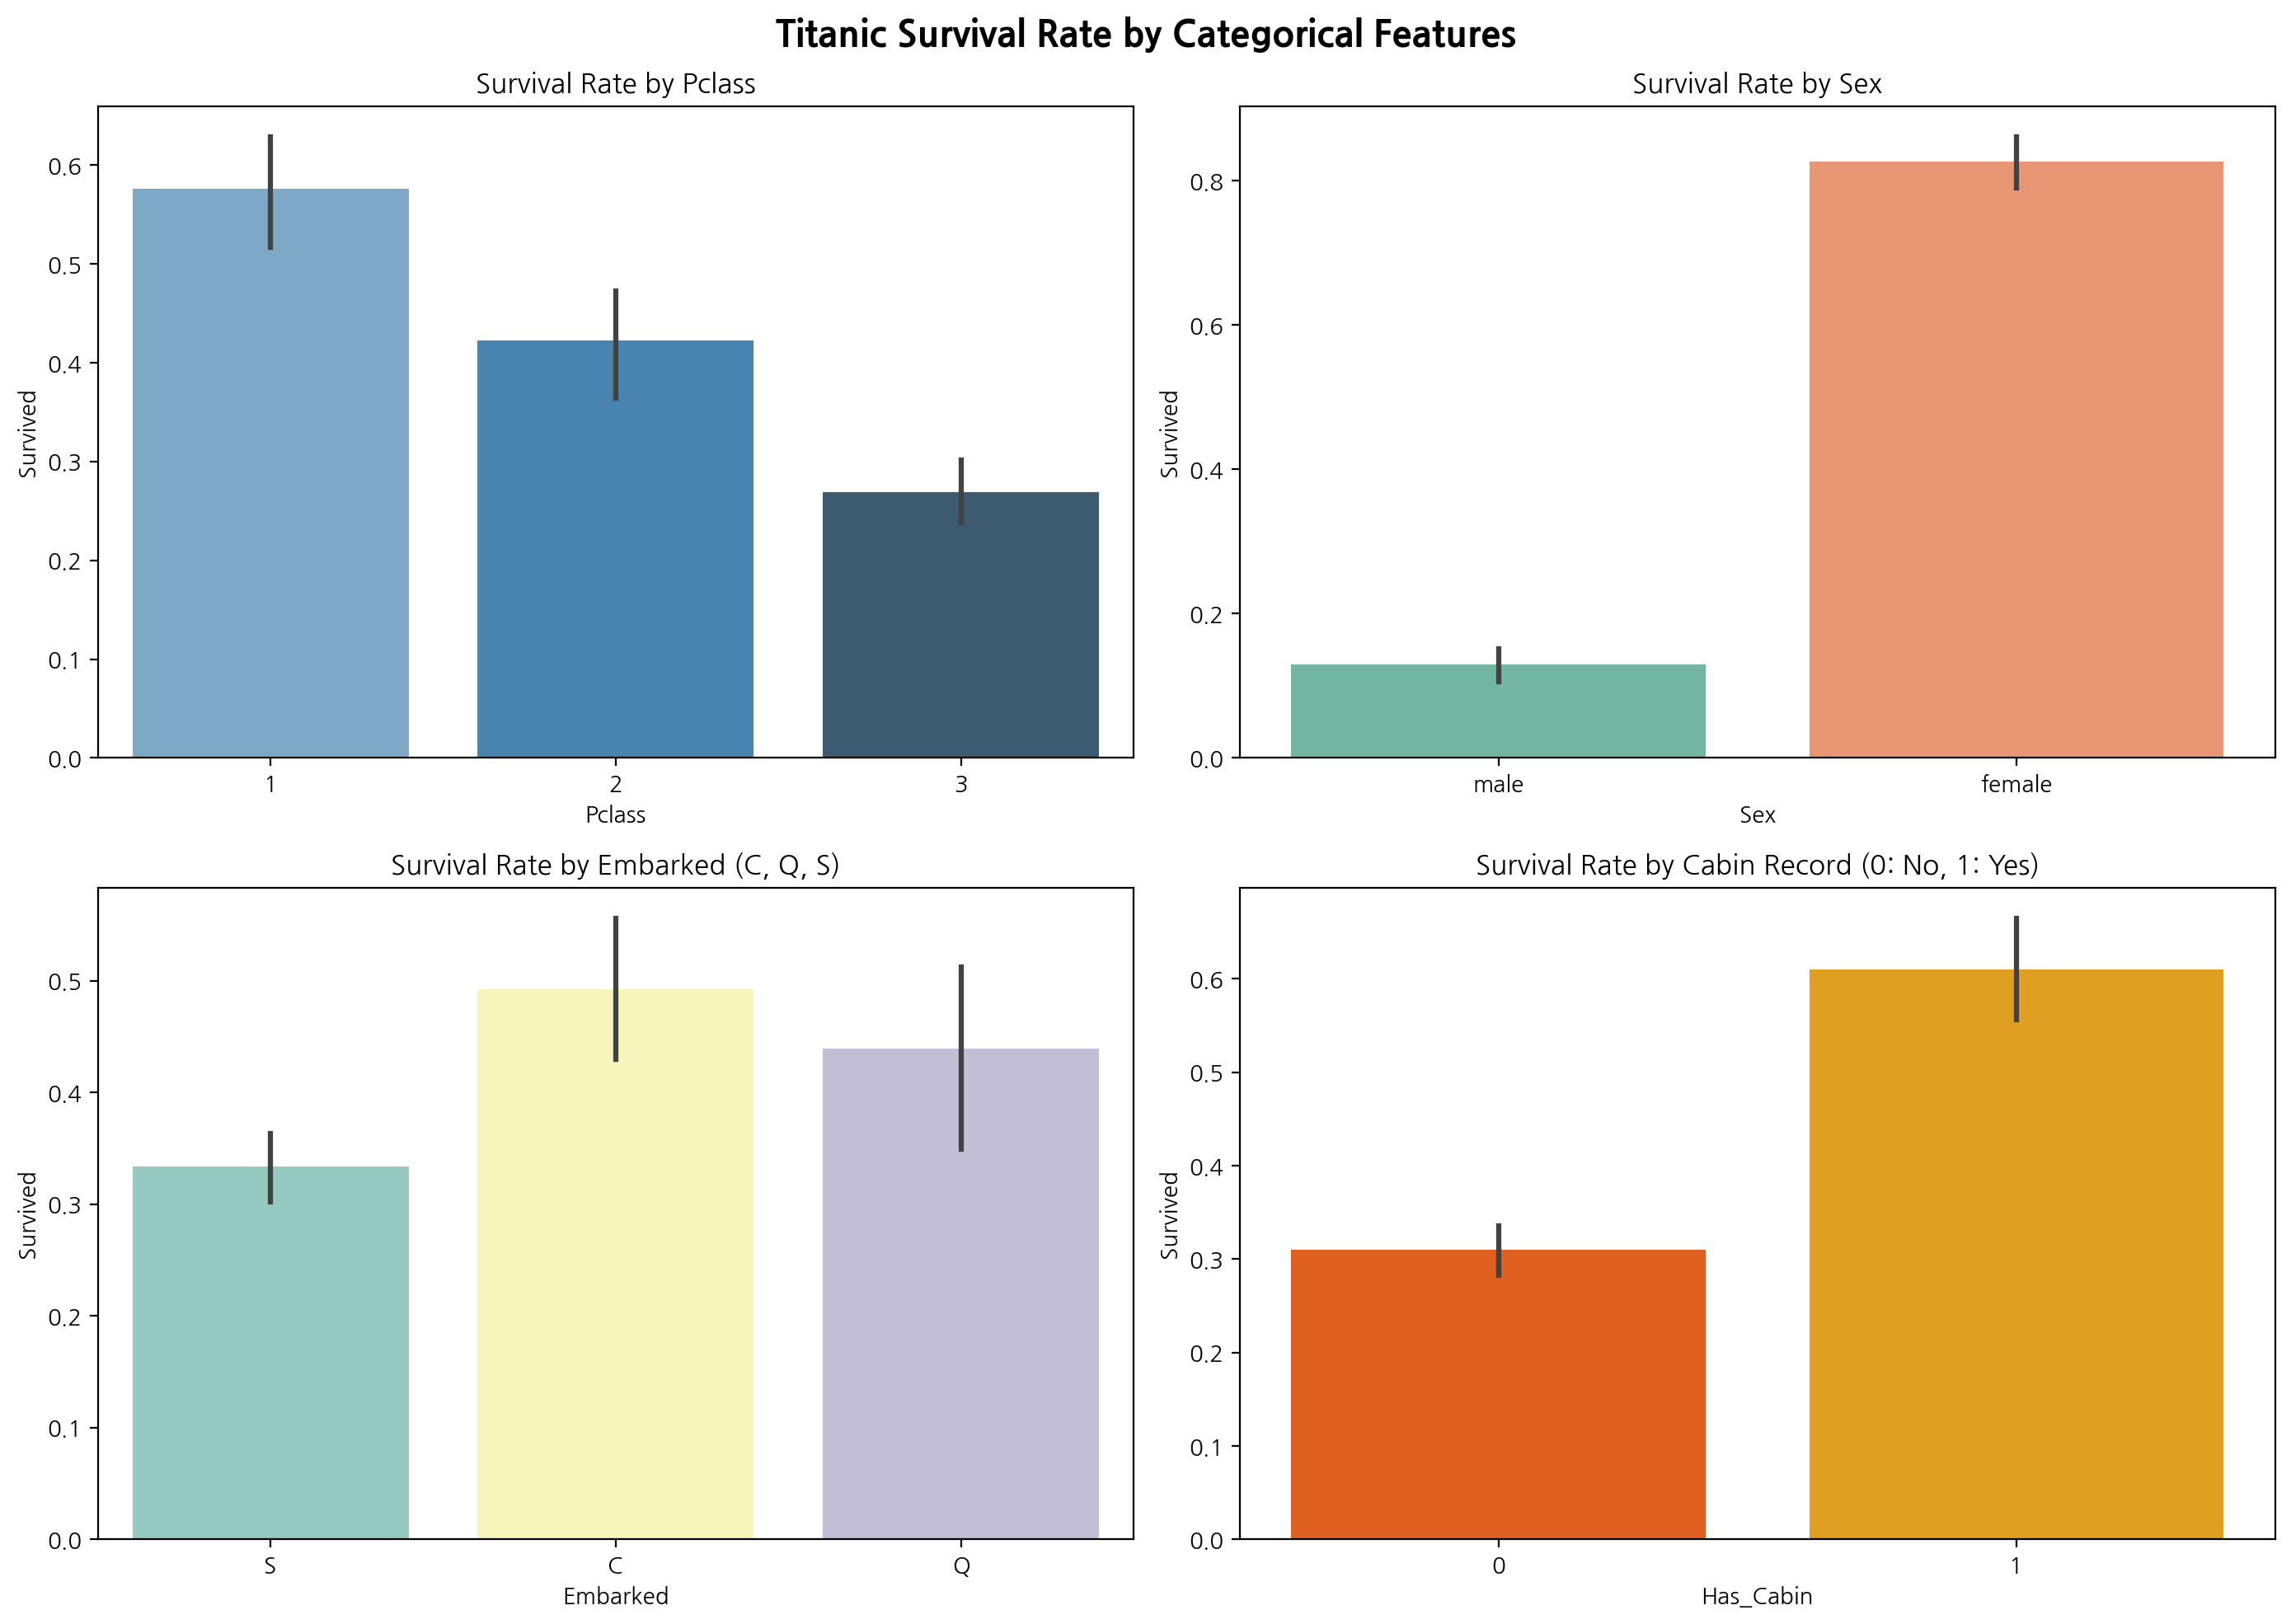

In [11]:
# 4. [Visualization 1] Categorical Variables vs Survival
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Titanic Survival Rate by Categorical Features', fontsize=16, fontweight='bold')

# ① Pclass
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[0, 0], palette='Blues_d')
axes[0, 0].set_title('Survival Rate by Pclass')

# ② Sex
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0, 1], palette='Set2')
axes[0, 1].set_title('Survival Rate by Sex')

# ③ Embarked
sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[1, 0], palette='Set3')
axes[1, 0].set_title('Survival Rate by Embarked (C, Q, S)')

# ④ Has_Cabin
sns.barplot(x='Has_Cabin', y='Survived', data=df, ax=axes[1, 1], palette='autumn')
axes[1, 1].set_title('Survival Rate by Cabin Record (0: No, 1: Yes)')

plt.tight_layout()
plt.show()

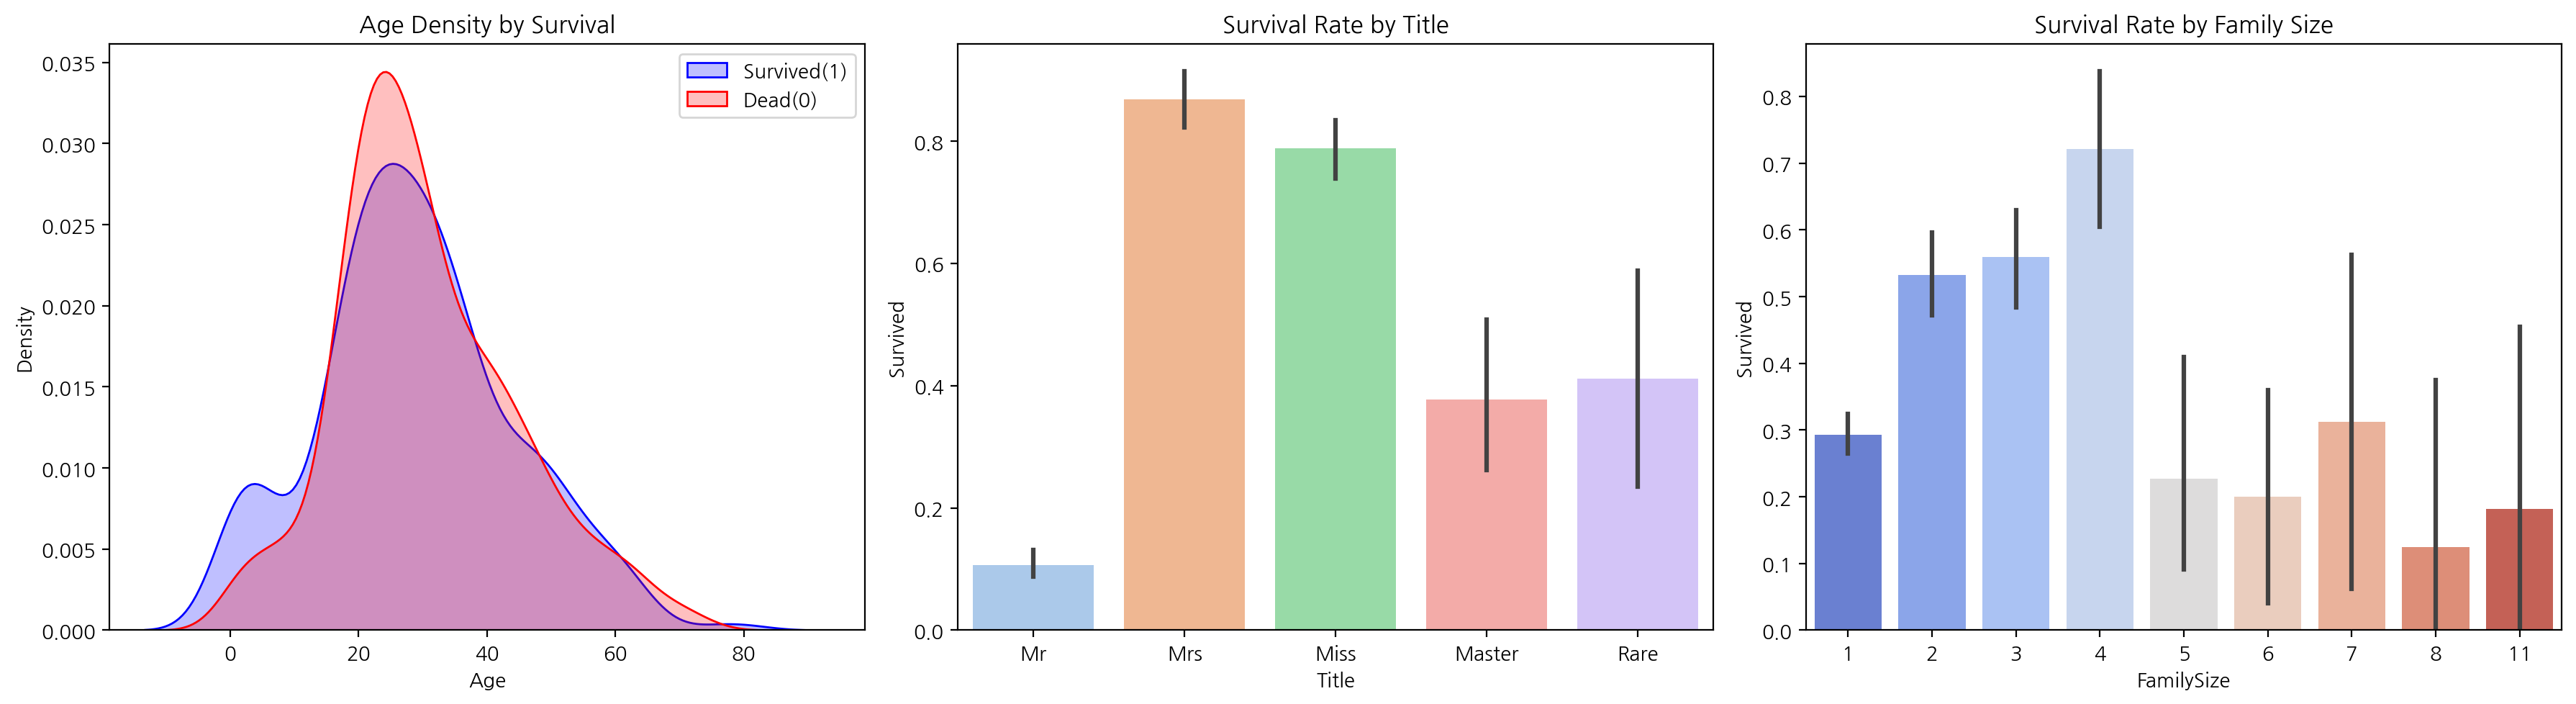

In [12]:
# 5. [Visualization 2] Continuous & Derived Variables
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ① Age KDE
sns.kdeplot(df[df['Survived']==1]['Age'], ax=axes[0], color='blue', fill=True, label='Survived(1)')
sns.kdeplot(df[df['Survived']==0]['Age'], ax=axes[0], color='red', fill=True, label='Dead(0)')
axes[0].set_title('Age Density by Survival')
axes[0].legend()

# ② Title
sns.barplot(x='Title', y='Survived', data=df, ax=axes[1], palette='pastel')
axes[1].set_title('Survival Rate by Title')

# ③ FamilySize
sns.barplot(x='FamilySize', y='Survived', data=df, ax=axes[2], palette='coolwarm')
axes[2].set_title('Survival Rate by Family Size')

plt.tight_layout()
plt.show()

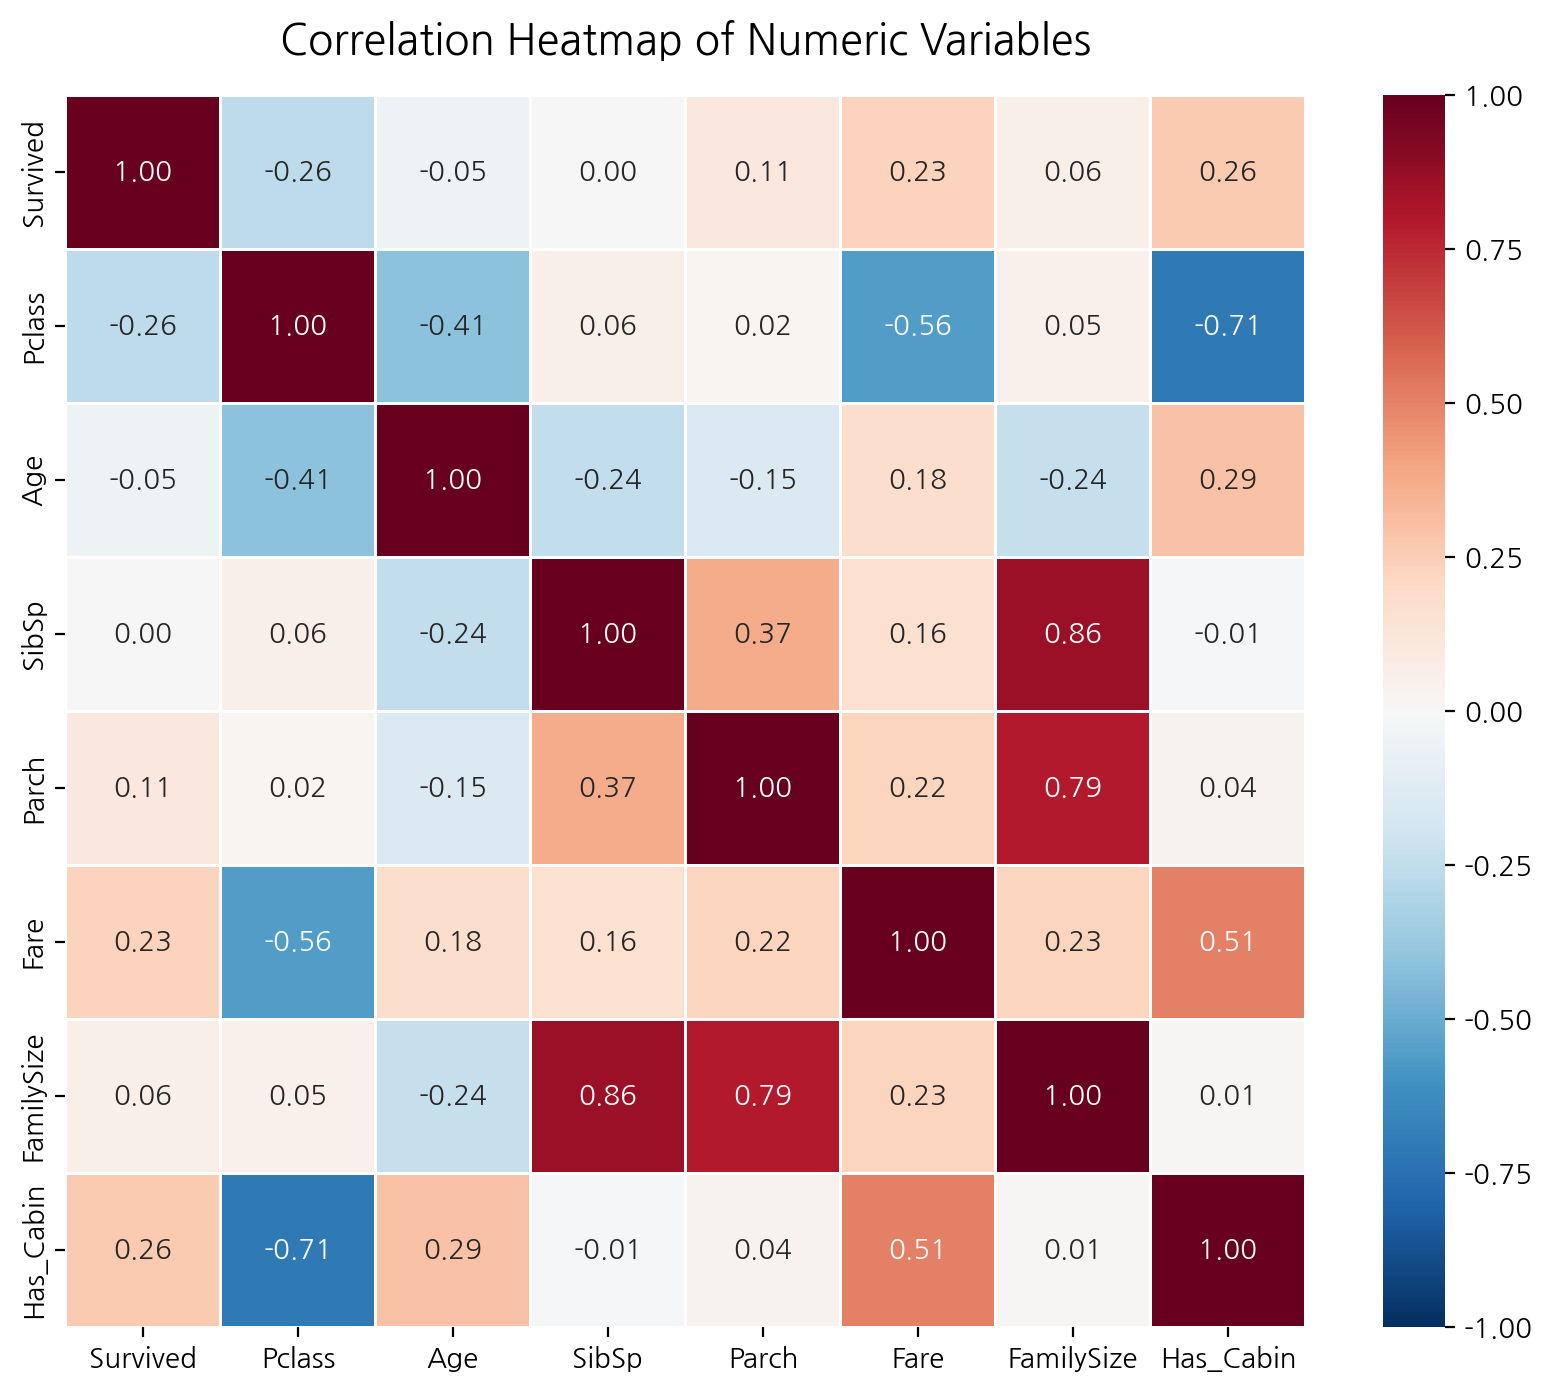

In [13]:
# 6. [Visualization 3] Correlation Heatmap
plt.figure(figsize=(10, 8))
numeric_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'Has_Cabin']
corr_matrix = df[numeric_cols].corr()

sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', vmin=-1, vmax=1, fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=15, pad=15)
plt.show()